# Demo — Metro Passenger Flow Forecast

**One clean input → output path**, runnable top-to-bottom in a fresh Google Colab or local runtime.

Given a **station** and a **current 15-minute interval**, the saved XGBoost model predicts
**how many passengers will enter that station in the next 15 minutes**, and maps it to a
crowding band (🟢 Low / 🟡 Medium / 🔴 High) for control-room staff.

- Model: `artifacts/metro_xgb_model.joblib` (selected on validation MAE = 22.42; test MAE = 25.75)
- Data: HZMetro (Hangzhou), CC-BY 4.0. Aggregated 15-min flow in `data/processed/flow_features.csv`.
- No retraining happens here — the demo loads the frozen artifact and predicts.

## 0. Environment setup (Colab-safe)
If the model artifact isn't present (fresh Colab), clone the repo and move into it.

In [1]:
import os

# Make the notebook run from the repository root whether launched from the
# repo root, from notebooks/, or from a fresh Colab with nothing cloned yet.
if os.path.exists("artifacts/metro_xgb_model.joblib"):
    pass                                   # already at repo root
elif os.path.exists("../artifacts/metro_xgb_model.joblib"):
    os.chdir("..")                         # launched from notebooks/
else:
    os.system("git clone --depth 1 https://github.com/muhammadmurodov/metro-flow-forecasting.git")
    if os.path.isdir("metro-flow-forecasting"):
        os.chdir("metro-flow-forecasting")  # fresh Colab

print("Working dir:", os.getcwd())
print("Artifact present:", os.path.exists("artifacts/metro_xgb_model.joblib"))

Working dir: /home/claude/repo
Artifact present: True


## 1. Load the frozen model + processed flow data

In [2]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt

# Selected inflow model (bundled with its feature list + recorded metrics)
inflow_art  = joblib.load("artifacts/metro_xgb_model.joblib")
outflow_art = joblib.load("artifacts/metro_xgb_outflow_model.joblib")

FEATURES = inflow_art["features"]
print("Model:", inflow_art["model_type"],
      "| val MAE:", round(inflow_art["val_mae"], 2),
      "| test MAE:", round(inflow_art["test_mae"], 2))
print("Expected feature columns:", FEATURES)

df = pd.read_csv("data/processed/flow_features.csv", parse_dates=["interval"])
names = pd.read_csv("data/station_names.csv")
station_names = dict(zip(names["stationID"], names["name"]))
print("Rows:", len(df), "| stations:", df.stationID.nunique(),
      "| range:", df.interval.min(), "->", df.interval.max())

/usr/lib/python3.12/pickle.py:1710: UserWarning: [10:05:04] WARNING: /__w/xgboost/xgboost/src/collective/../data/../common/error_msg.h:83: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  setstate(state)


Model: XGBoost | val MAE: 22.42 | test MAE: 25.75
Expected feature columns: ['stationID', 'hour', 'minute', 'dayofweek', 'is_weekend', 'inflow_lag_1', 'inflow_lag_2', 'inflow_lag_3', 'inflow_lag_4', 'inflow_roll_mean_4']


Rows: 152082 | stations: 80 | range: 2019-01-01 05:30:00 -> 2019-01-25 23:45:00


## 2. The prediction function
Everything the model needs (calendar fields + lag/rolling features) is already
computed per row in `flow_features.csv`, using only **past** intervals — so there is
no leakage. The function just looks up the chosen row and calls `.predict()`.

In [3]:
def crowding_band(p):
    if p < 100:   return "🟢 Low"
    if p < 300:   return "🟡 Medium"
    return "🔴 High"

def predict_next_15min(station_id, current_time, direction="inflow"):
    """Predict flow for the interval AFTER `current_time` at `station_id`.

    Returns a dict, or raises ValueError with a clear message on bad input.
    """
    art = inflow_art if direction == "inflow" else outflow_art

    if station_id not in df["stationID"].unique():
        raise ValueError(f"Unknown station {station_id}. Valid range: 0-80.")

    ts = pd.to_datetime(current_time)
    row = df[(df["stationID"] == station_id) & (df["interval"] == ts)]
    if row.empty:
        raise ValueError(
            f"No data for station {station_id} at {ts}. "
            "Pick a timestamp inside service hours (05:30-23:30, Jan 1-25 2019)."
        )

    pred = float(art["model"].predict(row[art["features"]])[0])
    return {
        "station": station_names.get(station_id, station_id),
        "current_time": ts,
        "predicts_interval": ts + pd.Timedelta(minutes=15),
        "predicted_" + direction: round(pred, 1),
        "crowding": crowding_band(pred),
        "actual_" + direction: int(row[direction].iloc[0]),  # ground truth, for reference
    }

print("Function ready.")

Function ready.


## 3. Example: one station, one timestamp

In [4]:
# A busy station during morning peak on a test-set day (model never trained on this).
example = predict_next_15min(station_id=15, current_time="2019-01-22 08:15:00")
for k, v in example.items():
    print(f"{k:>20}: {v}")

             station: Yan'an Road
        current_time: 2019-01-22 08:15:00
   predicts_interval: 2019-01-22 08:30:00
    predicted_inflow: 2468.5
            crowding: 🔴 High
       actual_inflow: 2544


## 4. Visual: recent history + the forecast point

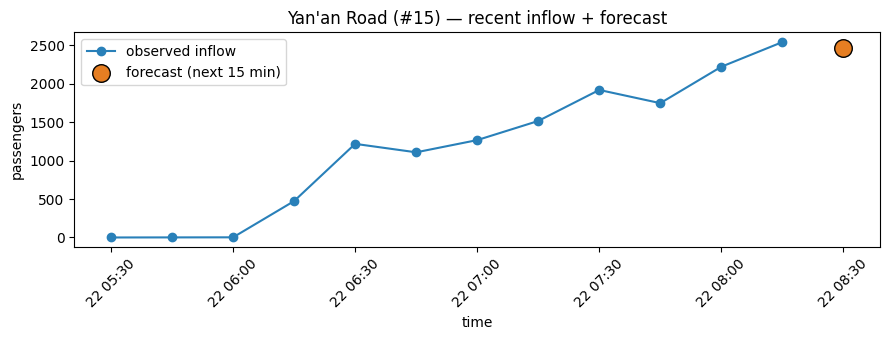

In [5]:
station_id = 15
current_time = pd.to_datetime("2019-01-22 08:15:00")
next_ts = current_time + pd.Timedelta(minutes=15)

hist = df[(df["stationID"] == station_id) & (df["interval"] <= current_time)].tail(12)
pred = predict_next_15min(station_id, current_time)["predicted_inflow"]

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(hist["interval"], hist["inflow"], marker="o", label="observed inflow", color="#2980b9")
ax.scatter([next_ts], [pred], s=160, color="#e67e22", edgecolor="black",
           zorder=5, label="forecast (next 15 min)")
ax.set_title(f"{station_names.get(station_id, station_id)} (#{station_id}) — recent inflow + forecast")
ax.set_xlabel("time"); ax.set_ylabel("passengers"); ax.legend()
plt.xticks(rotation=45); plt.tight_layout()
plt.show()

## 5. Input-validation check (safe failure)
The function refuses bad input with a clear message instead of crashing.

In [6]:
for bad in [(999, "2019-01-22 08:15:00"), (15, "2019-01-22 03:00:00")]:
    try:
        predict_next_15min(*bad)
    except ValueError as e:
        print("Rejected:", e)

Rejected: Unknown station 999. Valid range: 0-80.
Rejected: No data for station 15 at 2019-01-22 03:00:00. Pick a timestamp inside service hours (05:30-23:30, Jan 1-25 2019).


---
For the full interactive version (inflow/outflow selector, network crowding map),
see the deployed app: **https://metro-flow-forecasting.streamlit.app**